<a href="https://colab.research.google.com/github/Jyoti-Adhikari/FGSM-PGD-Adversarial-Attacks/blob/main/FGSM_PGD_Adversarial_Attacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt


In [3]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
GPU: Tesla T4


In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    './data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    './data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]

Training samples: 60000
Testing samples: 10000


Image shape: torch.Size([1, 28, 28])
Label: 5


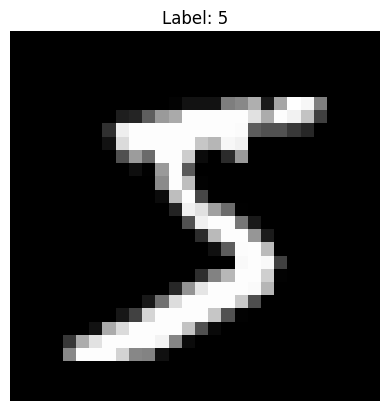

In [5]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [9]:
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)
        loss = F.cross_entropy(output, target)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

In [15]:
for epoch in range(1, 6):
    train(model, device, train_loader, optimizer, epoch)

Epoch 1: Loss = 0.0305
Epoch 2: Loss = 0.0218
Epoch 3: Loss = 0.0006
Epoch 4: Loss = 0.0145
Epoch 5: Loss = 0.0173


In [16]:
def test(model, device, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            prediction = output.argmax(dim=1)

            correct += prediction.eq(target).sum().item()
            total += target.size(0)

    accuracy = 100.0 * correct / total
    return accuracy

In [17]:
clean_accuracy = test(model, device, test_loader)

print(f"Clean Accuracy: {clean_accuracy:.2f}%")

Clean Accuracy: 98.91%


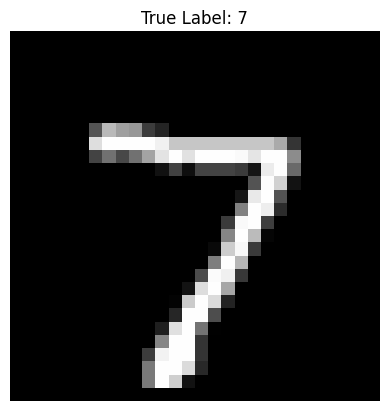

In [18]:
image, label = test_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"True Label: {label}")
plt.axis("off")
plt.show()

In [19]:
model.eval()

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    prediction = output.argmax(dim=1).item()

print("True label:", label)
print("Prediction:", prediction)

True label: 7
Prediction: 7


In [20]:
print(output)

tensor([[-10.4581,  -1.4123,  -6.0528,   1.0758,  -7.2158,  -6.9787, -22.0904,
          18.7971,  -7.9092,  -5.0220]], device='cuda:0')


In [21]:
torch.save(model.state_dict(), "simple_cnn_mnist.pth")